# Support Ticket Triage : Data Preparation & Exploratory Data Analysis

This notebook prepares the support-ticket dataset for the machine-learning stage.

### Objectives
- Validate the dataset structure and target labels.
- Assess missing values and duplicate tickets before cleaning.
- Create a modeling text field from `subject + body`.
- Explore issue type, priority, queue, ticket length, and useful priority keywords.
- Check relationships between `type` and `priority`.
- Export a clean ML-ready dataset.



In [3]:
 # 1. IMPORTS & CONFIGURATION
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "../Downloads/sam/ml_ready_support_tickets.csv"
OUTPUT_FILE = "ml_ready_support_tickets.csv"

EXPECTED_TYPES = {"incident", "request", "problem", "change"}
EXPECTED_PRIORITIES = {"high", "medium", "low"}

PRIORITY_ORDER = ["high", "medium", "low"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

In [4]:
 # 2. LOAD DATASET
 
df_raw = pd.read_csv(FILE_PATH, on_bad_lines="skip")

print("Original dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())

Original dataset shape: (17217, 19)

Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'norm_subj', 'norm_body', 'ticket_key']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,norm_subj,norm_body,ticket_key
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,account disruption,"dear customer support team,\n\ni am writing to...",account disruption || dear customer support te...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,query about smart home system integration feat...,"dear customer support team,\n\ni hope this mes...",query about smart home system integration feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,inquiry regarding invoice details,"dear customer support team,\n\ni hope this mes...",inquiry regarding invoice details || dear cust...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,question about marketing agency software compa...,"dear support team,\n\ni hope this message reac...",question about marketing agency software compa...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN,feature query,"dear customer support,\n\ni hope this message ...","feature query || dear customer support,\n\ni h..."


## 3. Initial Data Quality Assessment

The checks below are intentionally performed **before cleaning** so the original level of missingness, duplicates, and label quality is documented.

In [5]:
 # 3A. REQUIRED COLUMNS & DATA TYPES
 
required_columns = ["subject", "body", "type", "priority"]

missing_required = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

Data types:


,dtype
subject,object
body,object
answer,object
type,object
queue,object
priority,object
language,object
version,float64
tag_1,object
tag_2,object


In [6]:
 # 3B. MISSING VALUES BEFORE CLEANING
 

missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

print("Missing-value summary:")
display(missing_summary[missing_summary["missing_count"] > 0])

print("\nTotal missing cells:", int(df_raw.isna().sum().sum()))

Missing-value summary:


,missing_count,missing_percent
tag_8,15769,91.59
tag_7,14022,81.44
tag_6,11050,64.18
version,7188,41.75
tag_5,6123,35.56
tag_4,1289,7.49
tag_3,63,0.37
tag_2,14,0.08
answer,4,0.02



Total missing cells: 55522


In [7]:
 # 3C. DUPLICATE CHECKS BEFORE CLEANING
 
exact_duplicates = df_raw.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

temp_ticket_text = (
    df_raw["subject"].fillna("").astype(str).str.strip()
    + " "
    + df_raw["body"].fillna("").astype(str).str.strip()
).str.strip()

duplicate_ticket_texts = temp_ticket_text.duplicated().sum()
print("Duplicate subject+body tickets:", duplicate_ticket_texts)

Exact duplicate rows: 0
Duplicate subject+body tickets: 0


## 4. Data Cleaning

Target rows with missing `type` or `priority` are removed **before** string conversion. This prevents missing labels from accidentally becoming the literal string `"nan"`.

In [8]:

# 4. DATA CLEANING


df = df_raw.copy()

# Remove columns that are entirely or mostly unused in this dataset.
df = df.drop(columns=["tag_7", "tag_8"], errors="ignore")

# Remove rows with missing target labels Before converting targets to strings.
df = df.dropna(subset=["type", "priority"]).copy()

# Customer text may legitimately have one missing component.
df["subject"] = df["subject"].fillna("").astype(str).str.strip()
df["body"] = df["body"].fillna("").astype(str).str.strip()

# Normalize target labels.
df["type"] = df["type"].astype(str).str.strip().str.lower()
df["priority"] = df["priority"].astype(str).str.strip().str.lower()

# Combined text used by the ML pipeline.
df["text"] = (df["subject"] + " " + df["body"]).str.strip()

# Remove empty tickets.
df = df[df["text"].str.len() > 0].copy()

print("Shape after basic cleaning:", df.shape)

Shape after basic cleaning: (17217, 18)


In [9]:
 # 5. LABEL VALIDATION

unexpected_types = set(df["type"].unique()) - EXPECTED_TYPES
unexpected_priorities = set(df["priority"].unique()) - EXPECTED_PRIORITIES

print("Unexpected issue types:", unexpected_types)
print("Unexpected priorities:", unexpected_priorities)

if unexpected_types:
    raise ValueError(f"Unexpected issue-type labels found: {unexpected_types}")

if unexpected_priorities:
    raise ValueError(f"Unexpected priority labels found: {unexpected_priorities}")

Unexpected issue types: set()
Unexpected priorities: set()


In [10]:
 # 6. DUPLICATE & CONFLICTING-LABEL ANALYSIS


duplicate_analysis = (
    df.groupby("text")
      .agg(
          ticket_count=("text", "size"),
          unique_type_labels=("type", "nunique"),
          unique_priority_labels=("priority", "nunique")
      )
      .reset_index()
)

duplicate_groups = duplicate_analysis[
    duplicate_analysis["ticket_count"] > 1
]

conflicting_duplicates = duplicate_groups[
    (duplicate_groups["unique_type_labels"] > 1)
    | (duplicate_groups["unique_priority_labels"] > 1)
]

print("Duplicate text groups:", len(duplicate_groups))
print("Duplicate groups with conflicting labels:", len(conflicting_duplicates))

# Remove only exact duplicate text+target combinations.
# Conflicting duplicate labels are retained for investigation rather than silently removed.
before = len(df)
df = df.drop_duplicates(subset=["text", "type", "priority"]).copy()

print("Rows removed as exact ticket/label duplicates:", before - len(df))
print("Current usable tickets:", len(df))

Duplicate text groups: 0
Duplicate groups with conflicting labels: 0
Rows removed as exact ticket/label duplicates: 0
Current usable tickets: 17217


# 7. Exploratory Data Analysis

The EDA is focused on variables that directly support modeling decisions

In [11]:
 # 7A. TARGET DISTRIBUTIONS


type_summary = pd.DataFrame({
    "count": df["type"].value_counts(),
    "percent": (df["type"].value_counts(normalize=True) * 100).round(2)
})

priority_summary = pd.DataFrame({
    "count": df["priority"].value_counts(),
    "percent": (df["priority"].value_counts(normalize=True) * 100).round(2)
})

print("Issue Type Distribution")
display(type_summary)

print("Priority Distribution")
display(priority_summary)

Issue Type Distribution


,count,percent
incident,6843,39.75
request,5028,29.20
problem,3555,20.65
change,1791,10.40


Priority Distribution


,count,percent
medium,7134,41.44
high,6582,38.23
low,3501,20.33


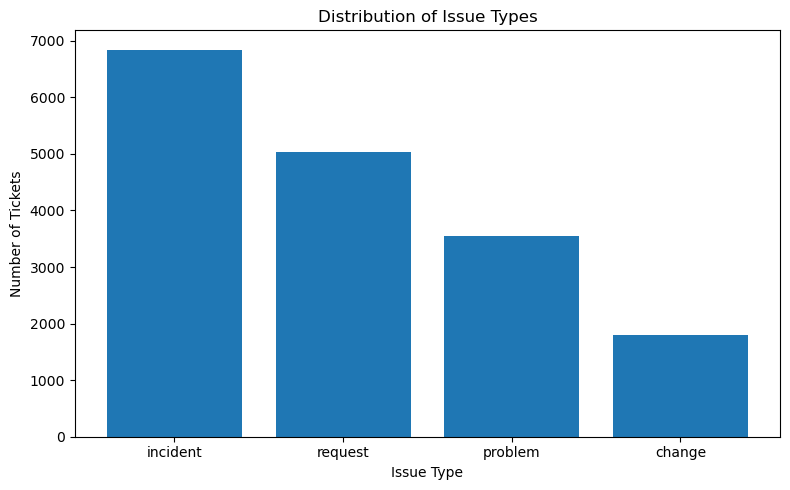

In [12]:
# Plot Issue Type Distribution

type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Distribution of Issue Types")
plt.xlabel("Issue Type")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

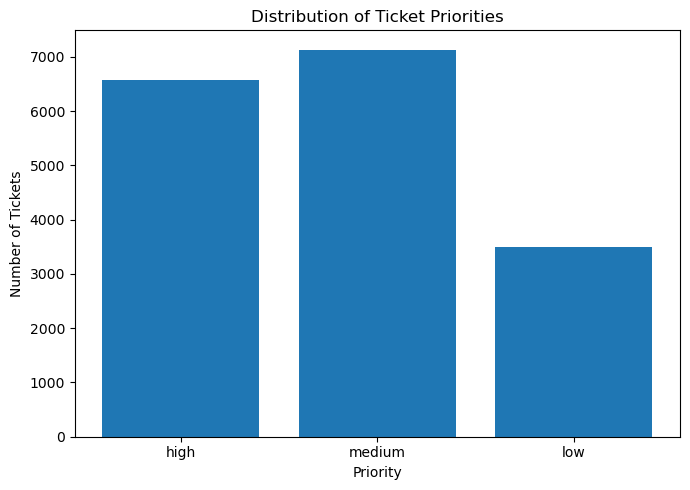

In [13]:
# Plot Priority Distribution

priority_counts = df["priority"].value_counts().reindex(PRIORITY_ORDER)

plt.figure(figsize=(7, 5))
plt.bar(priority_counts.index, priority_counts.values)
plt.title("Distribution of Ticket Priorities")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [14]:
 # 7B. ISSUE TYPE × PRIORITY


type_priority_count = pd.crosstab(
    df["type"],
    df["priority"]
).reindex(columns=PRIORITY_ORDER)

type_priority_pct = (
    pd.crosstab(
        df["type"],
        df["priority"],
        normalize="index"
    )
    .reindex(columns=PRIORITY_ORDER)
    .mul(100)
    .round(2)
)

print("Issue Type × Priority — Counts")
display(type_priority_count)

print("Issue Type × Priority — Row Percentages")
display(type_priority_pct)

Issue Type × Priority — Counts


priority,high,medium,low
type,,,
change,708,731,352
incident,2893,2681,1269
problem,1300,1518,737
request,1681,2204,1143


Issue Type × Priority — Row Percentages


priority,high,medium,low
type,,,
change,39.53,40.82,19.65
incident,42.28,39.18,18.54
problem,36.57,42.70,20.73
request,33.43,43.83,22.73


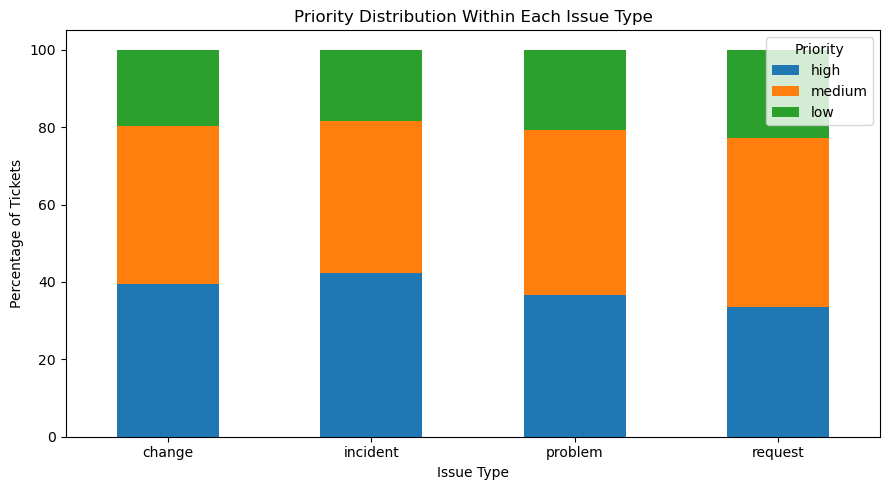

In [15]:
# Stacked percentage chart: Priority within each Issue Type

type_priority_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Priority Distribution Within Each Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Percentage of Tickets")
plt.xticks(rotation=0)
plt.legend(title="Priority")
plt.tight_layout()
plt.show()

,count,percent
Technical Support,4984,28.95
Product Support,3195,18.56
Customer Service,2597,15.08
IT Support,2047,11.89
Billing and Payments,1763,10.24
Returns and Exchanges,840,4.88
Service Outages and Maintenance,698,4.05
Sales and Pre-Sales,520,3.02
Human Resources,326,1.89
General Inquiry,247,1.43


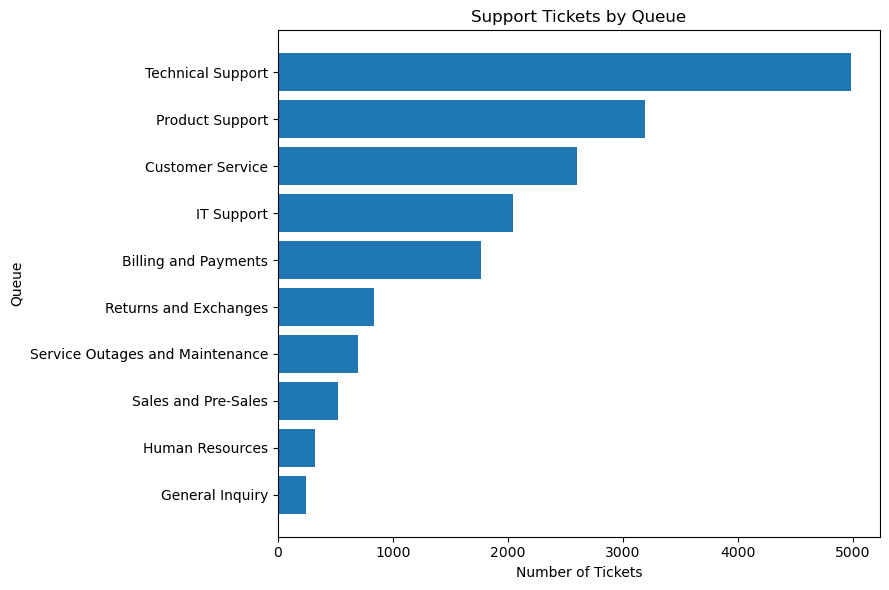

In [16]:
 # 7C. QUEUE DISTRIBUTION


if "queue" in df.columns:
    queue_summary = pd.DataFrame({
        "count": df["queue"].value_counts(),
        "percent": (df["queue"].value_counts(normalize=True) * 100).round(2)
    })

    display(queue_summary)

    queue_counts = df["queue"].value_counts().sort_values()

    plt.figure(figsize=(9, 6))
    plt.barh(queue_counts.index, queue_counts.values)
    plt.title("Support Tickets by Queue")
    plt.xlabel("Number of Tickets")
    plt.ylabel("Queue")
    plt.tight_layout()
    plt.show()

priority,high,medium,low
queue,,,
Billing and Payments,30.91,47.76,21.33
Customer Service,18.79,49.21,32.00
General Inquiry,12.55,25.51,61.94
Human Resources,10.43,40.18,49.39
IT Support,46.90,43.19,9.92
Product Support,28.86,52.36,18.78
Returns and Exchanges,20.36,40.71,38.93
Sales and Pre-Sales,17.31,48.08,34.62
Service Outages and Maintenance,70.92,16.76,12.32


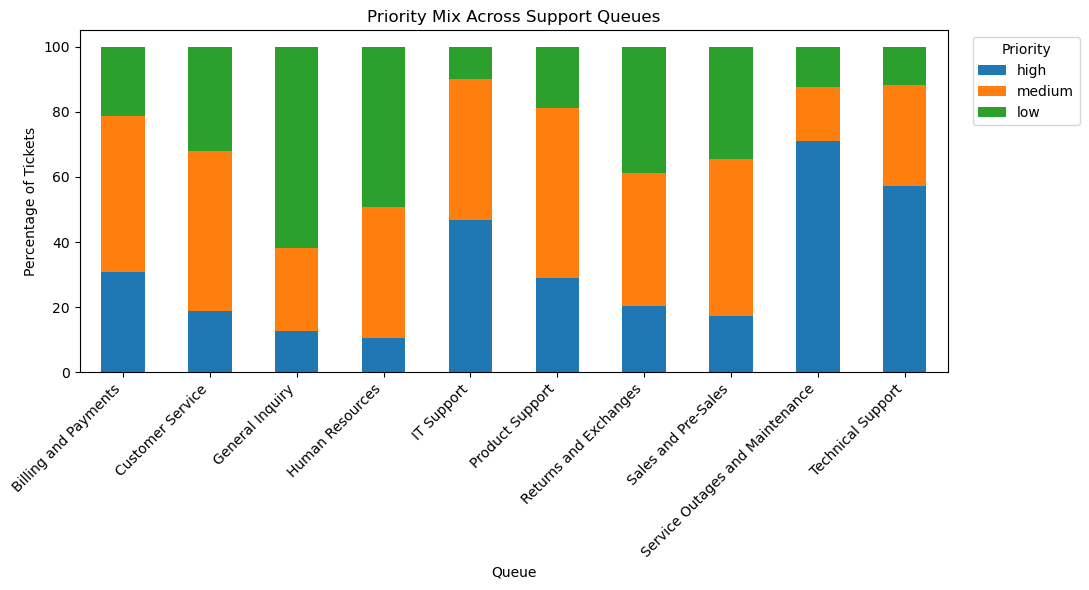

In [17]:

# 7D. QUEUE × PRIORITY
 
if "queue" in df.columns:
    queue_priority_pct = (
        pd.crosstab(
            df["queue"],
            df["priority"],
            normalize="index"
        )
        .reindex(columns=PRIORITY_ORDER)
        .mul(100)
        .round(2)
    )

    display(queue_priority_pct)

    queue_priority_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6)
    )

    plt.title("Priority Mix Across Support Queues")
    plt.xlabel("Queue")
    plt.ylabel("Percentage of Tickets")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Priority", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 8. Text-Length Analysis

Ticket length is useful in NLP EDA because extremely short or unusually long tickets can affect classification performance.

In [18]:
 # 8A. TEXT-LENGTH FEATURES
 
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

print("Overall Ticket-Length Statistics")
display(df[["word_count", "char_count"]].describe().round(2))

print("Word Count by Issue Type")
display(
    df.groupby("type")["word_count"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

print("Word Count by Priority")
display(
    df.groupby("priority")["word_count"]
      .agg(["count", "mean", "median", "min", "max"])
      .reindex(PRIORITY_ORDER)
      .round(2)
)

Overall Ticket-Length Statistics


,word_count,char_count
count,17217.00,17217.00
mean,62.07,421.29
std,33.53,217.49
min,4.00,35.00
25%,35.00,242.00
50%,60.00,413.00
75%,85.00,584.00
max,276.00,1825.00


Word Count by Issue Type


,count,mean,median,min,max
type,,,,,
change,1791,66.76,71.0,6,247
incident,6843,61.02,58.0,5,232
problem,3555,60.02,55.0,4,276
request,5028,63.28,65.0,6,257


Word Count by Priority


,count,mean,median,min,max
priority,,,,,
high,6582,61.50,60.0,4,217
medium,7134,62.58,61.0,6,257
low,3501,62.12,60.0,5,276


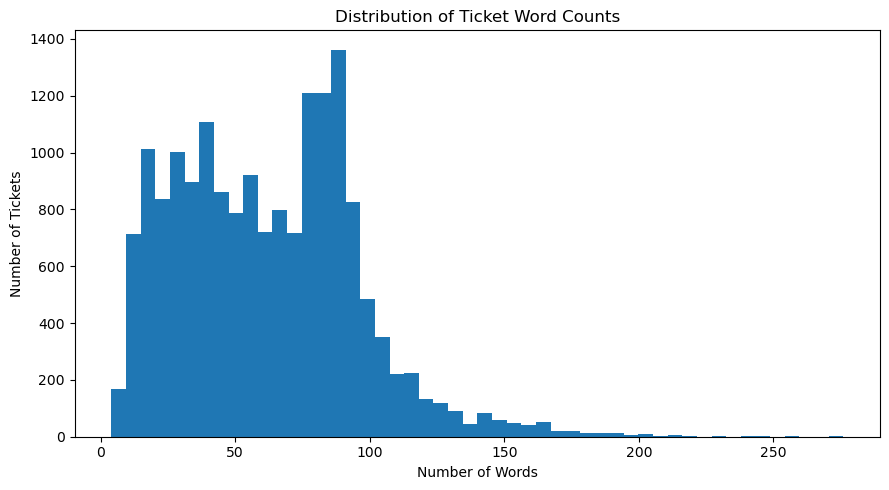

In [19]:
# Ticket word-count distribution

plt.figure(figsize=(9, 5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Ticket Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [20]:
# Inspect unusually short tickets

SHORT_TICKET_THRESHOLD = 3

short_tickets = df[df["word_count"] <= SHORT_TICKET_THRESHOLD]

print(
    f"Tickets with {SHORT_TICKET_THRESHOLD} words or fewer:",
    len(short_tickets)
)

display(
    short_tickets[
        ["subject", "body", "type", "priority", "word_count"]
    ].head(10)
)

Tickets with 3 words or fewer: 0


,subject,body,type,priority,word_count


## 9. Priority Keyword Analysis


In [21]:
# 9. PRIORITY KEYWORD ANALYSIS
 
keywords = [
    "urgent",
    "immediate",
    "critical",
    "severe",
    "emergency",
    "outage",
    "down",
    "blocked",
    "blocking",
    "unable",
    "failure",
    "failed",
    "security",
    "unauthorized"
]

keyword_results = []

text_lower = df["text"].str.lower()

for keyword in keywords:
    mask = text_lower.str.contains(keyword, regex=False, na=False)
    subset = df.loc[mask]

    if subset.empty:
        continue

    counts = (
        subset["priority"]
        .value_counts()
        .reindex(PRIORITY_ORDER, fill_value=0)
    )

    keyword_results.append({
        "keyword": keyword,
        "ticket_count": len(subset),
        "high": counts["high"],
        "medium": counts["medium"],
        "low": counts["low"],
        "high_percent": round(counts["high"] / len(subset) * 100, 2),
        "medium_percent": round(counts["medium"] / len(subset) * 100, 2),
        "low_percent": round(counts["low"] / len(subset) * 100, 2)
    })

keyword_df = (
    pd.DataFrame(keyword_results)
      .sort_values(["high_percent", "ticket_count"], ascending=[False, False])
      .reset_index(drop=True)
)

display(keyword_df)

,keyword,ticket_count,high,medium,low,high_percent,medium_percent,low_percent
0,blocking,5,5,0,0,100.00,0.00,0.00
1,severe,134,104,21,9,77.61,15.67,6.72
2,outage,547,367,142,38,67.09,25.96,6.95
3,critical,516,308,149,59,59.69,28.88,11.43
4,urgent,1092,620,339,133,56.78,31.04,12.18
5,immediate,657,370,218,69,56.32,33.18,10.50
6,down,533,290,175,68,54.41,32.83,12.76
7,failure,879,473,292,114,53.81,33.22,12.97
8,emergency,10,5,3,2,50.00,30.00,20.00
9,unable,275,124,105,46,45.09,38.18,16.73


## 11. Final Modeling Dataset



In [23]:
 # 11. FINAL MODELING DATASET
 
modeling_columns = [
    "subject",
    "body",
    "text",
    "type",
    "priority"
]

ml_df = df[modeling_columns].copy()

print("Final ML-ready shape:", ml_df.shape)
print("\nFinal missing values:")
print(ml_df.isna().sum())

print("\nFinal Issue Type Distribution:")
print(ml_df["type"].value_counts())

print("\nFinal Priority Distribution:")
print(ml_df["priority"].value_counts())

display(ml_df.head())

Final ML-ready shape: (17217, 5)

Final missing values:
subject     0
body        0
text        0
type        0
priority    0
dtype: int64

Final Issue Type Distribution:
incident    6843
request     5028
problem     3555
change      1791
Name: type, dtype: int64

Final Priority Distribution:
medium    7134
high      6582
low       3501
Name: priority, dtype: int64


,subject,body,text,type,priority
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...",incident,high
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,request,medium
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,request,low
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,problem,medium
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",request,high


In [ ]:
# ==============================================================================
# 12. EXPORT
# ==============================================================================

ml_df.to_csv(OUTPUT_FILE, index=False)

print(f"Saved successfully as: {OUTPUT_FILE}")
print(f"Rows exported: {len(ml_df)}")

# Next Step: Modeling

The exported file can now be used by the classification notebook:

- **Input:** `subject + body` / `text`
- **Target 1:** `type`
- **Target 2:** `priority`
- **Feature extraction:** TF-IDF
- **Evaluation:** Macro-F1, per-class precision/recall/F1, confusion matrix
- **Priority business evaluation:** cost-sensitive errors, especially `High → Low`

